# ML3 - Validation

# 1. Theory

## 1) Leave-One-Out CV

* Each learning set is created by taking **all the samples except one**, the test set being the sample left out. Thus, for $n$ samples, we have $n$ different training sets and $n$ different test sets.
#### Pros
-  **does not waste much data** as only one sample is removed from `valid`
-  models constructed from folds are virtually identical to each other and to the model built from the entire training set
-  **if the learning curve is steep** for the training size in question, then 5 or 10-fold cross validation can overestimate the generalization error

#### Cons
-  high variance for the test error
- **computationally expensive**

## 2) Grid Search methods

#### Basic Grid Search
- tries **every possible combination** of these parameter values -> can be **computationally very expensive**

    ##### How it works:
*   Define a grid of hyperparameter values. (e.g., `learning_rate`: [0.1, 0.01, 0.001], `max_depth`: [3, 5, 10])
*   Systematically train and evaluate a model for **each unique combination**
*   Select the combination yielding the best performance metric

---

#### Randomized Grid Search

- **randomly samples a fixed number of combinations** from the specified *distributions* (or lists) for each hyperparameter

    ##### How it works:
*   Define search spaces (can be distributions, not just lists). (e.g., `learning_rate`: uniform(0.001, 0.1), `max_depth`: randint(3, 15))
*   Set a number of iterations (`n_iter`)
*   Randomly draw a set of hyperparameters for each iteration
*   Select the best performing sample

---

#### Bayesian Optimization

- builds a **probabilistic model** (called a **surrogate model**, often a Gaussian Process) that maps hyperparameters to the probability of a score on the objective function (like validation accuracy)
- uses this model to decide the next set of hyperparameters to evaluate by balancing **exploration** (trying points in uncertain regions) and **exploitation** (trying points expected to be good)
- the next combination to try is decided by the **acquisition function** (Expected Improvement, Upper/Lower Confidence Bound etc.)
- typically requires **far fewer evaluations** than Grid or Randomized Search -> highly efficient for expensive-to-evaluate models (like deep neural networks)
- popular libraries include Hyperopt, Optuna, and Scikit-Optimize.

## 3) Feature Selection

- **Unsupervised methods** don’t need access to the target variable of the machine learning model, **supervised use target**
    - unsupervised methods like droppping multicollinear features usually precede, because most more sophisticated feature selection methods struggle to deal with multicollinearity
  ## Wrappers
- uses a model to score different subsets of features to finally select the best one: each new subset is used to train a model whose performance is then evaluated on a hold-out set
- provide the best-performing feature set for the particular chosen type of model 
- likely to overfit to the model type
- large computational needs
  ## Filters
- simply analyze single feature's statistical relation with the target, using measures such as correlation or mutual information as a proxy for the model performance metric
- model-agnostic, so they won’t overfit to any particular model
- easy to interpret using statistical relationship
- look at each feature in isolation, this makes them prone to discarding useful features that are weak predictors of the target on their own but add a lot of value to the model when combined with other features
    #### Pearson r (Pearson correlation)
$$\Large r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$
- used for interval (e.g. temperature) or ratio (e.g. price) variables (**numerical**)
- assumes normal distribution
- only measures the linear correlation - when the correlation is non-linear, Pearson’s r won’t detect it, even if it’s really strong
- non-parametric alternatives: Kendall Tau, Spearman Rho
    #### Chi-Sqaured
$$\Large \chi^2 = \sum_{i=1}^{k} \sum_{j=1}^{m} \frac{\left(n_{ij} - \frac{R_i C_j}{N}\right)^2}{\frac{R_i C_j}{N}}$$
  $\large k$ - number of categories in the feature
  
  $\large m$ - number of classes in the target
  
  $\large n_{ij}$ - observed count in cell $(i,j)$ of contingency table
  
  $\large R_i$ - row total for feature category 
  
  $\large C_j$ - column total for target class 

  $\large N$ - total number of samples

  <img src="../misc/images/contingency_table.png" alt="contingency table" width="600" height="400">

  - to determine whether two **categorical variables** are related
  - works by comparing the observed and the expected frequencies: the expected frequencies are such that the proportions of one variable are the same for all values of the other variable (like under assumption that there is no relationship between two variables)


  ## Embedded
- fast to compute
- few algorithms with feature selection built-in (only LASSO, auto-encoders with a bottleneck; tree-based models can be used but they might overestimate high cardinality features)
    - **L1 penalty**
  $$\Large {λ}||{θ}||^1_1 = \sum_{i=1}^{d}{|θ_i|}$$
    - adding L1 penaly leads to some coefficients being zeroed, thus L1 regularization is applicable to **feature selection**

  ## Permutation importance
- **randomly shuffling** the values of a single feature and observing the resulting degradation of the model’s score - by breaking the relationship between the feature and the target, we determine how much the model relies on such particular feature
- particularly useful for **non-linear or opaque estimators**
- **model-agnostic**, i.e. it can be applied to any fitted estimator
- can be calculated multiple times with different permutations of the feature, further providing a measure of the variance in the estimated feature importances
- realtively low computational costs
  ### Algorithm:
  <img src="../misc/images/permutation_importance.png" alt="permutation importance" width="600" height="400">

# 2. Import, load data, create new features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import shap
from tqdm.notebook import tqdm
from collections import Counter
from itertools import product
from functools import reduce

In [2]:
data = pd.read_json('../datasets/train.json')

#### get 20 most frequent features

In [3]:
all_features = []
for idx, row in data.iterrows():
    all_features += row['features']

top_20 = [feature for feature, count in Counter(all_features).most_common(20)]

for feature in top_20:
    data[feature.replace(' ', '')] = data.apply(lambda row: int((feature in row['features'])), axis=1)

top_20 = [f.replace(' ', '') for f in top_20]
feature_list = ['bathrooms', 'bedrooms', 'interest_level'] + top_20

#### encode `interest_level`

In [4]:
enc = sklearn.preprocessing.OrdinalEncoder(categories=[['low', 'medium', 'high']])
data['interest_level'] = (enc.fit_transform(data[['interest_level']]))
data['interest_level'] = data['interest_level'].astype(int)

In [5]:
data.head(3)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,...,1,0,0,0,0,0,0,0,0,0


In [88]:
top_20

['Elevator',
 'CatsAllowed',
 'HardwoodFloors',
 'DogsAllowed',
 'Doorman',
 'Dishwasher',
 'NoFee',
 'LaundryinBuilding',
 'FitnessCenter',
 'Pre-War',
 'LaundryinUnit',
 'RoofDeck',
 'OutdoorSpace',
 'DiningRoom',
 'HighSpeedInternet',
 'Balcony',
 'SwimmingPool',
 'LaundryInBuilding',
 'NewConstruction',
 'Terrace']

In [6]:
data = data[feature_list + ['price']]
X = data[feature_list]
y = data['price']

In [87]:
X

,bathrooms,bedrooms,interest_level,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,NoFee,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,1,0,1,1,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,0,1,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,1,1,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
124002,1.0,2,1,1,1,0,1,1,0,1,...,0,0,0,0,0,0,0,1,0,0
124004,1.0,1,1,1,1,1,1,0,1,1,...,1,0,0,1,0,0,0,0,0,0
124008,1.0,2,1,0,0,0,0,0,1,1,...,1,0,1,0,0,0,0,0,0,0


# 3. `my_data_split`

In [7]:
from my_validation import my_data_split

- split data into 2 parts randomly with parameter `test_size`

In [8]:
[x.shape for x in my_data_split(X=X, y=y, test_size=0.2)]

[(39482, 23), (9870, 23), (39482,), (9870,)]

- split data into 3 parts randomly with parameters `validation_size` and `test_size`

In [9]:
[x.shape for x in my_data_split(X=X, y=y, test_size=0.2, validation_size=0.2)]

[(29612, 23), (9870, 23), (9870, 23), (29612,), (9870,), (9870,)]

- create dataframe with `time` feature for time-based splits

In [10]:
X_dated = X.copy()
X_dated['time'] = pd.date_range('2020-01-01', periods=X.shape[0], freq='h')
X_dated['time']

4        2020-01-01 00:00:00
6        2020-01-01 01:00:00
9        2020-01-01 02:00:00
10       2020-01-01 03:00:00
15       2020-01-01 04:00:00
                 ...        
124000   2025-08-18 03:00:00
124002   2025-08-18 04:00:00
124004   2025-08-18 05:00:00
124008   2025-08-18 06:00:00
124009   2025-08-18 07:00:00
Name: time, Length: 49352, dtype: datetime64[ns]

- split data into 2 parts with parameter `test_date`

In [11]:
[x.shape for x in my_data_split(X=X_dated, y=y, date_column='time', test_date='2025-01-01')]

[(43848, 24), (5504, 24), (43848,), (5504,)]

In [12]:
[x.time for x in my_data_split(X=X_dated, y=y, date_column='time', test_date='2025-01-01')[0:2]]

[4        2020-01-01 00:00:00
 6        2020-01-01 01:00:00
 9        2020-01-01 02:00:00
 10       2020-01-01 03:00:00
 15       2020-01-01 04:00:00
                  ...        
 110252   2024-12-31 19:00:00
 110254   2024-12-31 20:00:00
 110255   2024-12-31 21:00:00
 110257   2024-12-31 22:00:00
 110258   2024-12-31 23:00:00
 Name: time, Length: 43848, dtype: datetime64[ns],
 110259   2025-01-01 00:00:00
 110266   2025-01-01 01:00:00
 110267   2025-01-01 02:00:00
 110268   2025-01-01 03:00:00
 110271   2025-01-01 04:00:00
                  ...        
 124000   2025-08-18 03:00:00
 124002   2025-08-18 04:00:00
 124004   2025-08-18 05:00:00
 124008   2025-08-18 06:00:00
 124009   2025-08-18 07:00:00
 Name: time, Length: 5504, dtype: datetime64[ns]]

- split data into 3 parts with parameters `validation_date` and `test_date`

In [13]:
[x.shape for x in my_data_split(X=X_dated, y=y, date_column='time', test_date='2025-01-01', validation_date='2024-01-01')]


[(35064, 24), (8784, 24), (5504, 24), (35064,), (8784,), (5504,)]

In [14]:
[x.time for x in my_data_split(X=X_dated, y=y, date_column='time',
                               test_date='2025-01-01',
                               validation_date='2024-01-01')[0:3]]


[4       2020-01-01 00:00:00
 6       2020-01-01 01:00:00
 9       2020-01-01 02:00:00
 10      2020-01-01 03:00:00
 15      2020-01-01 04:00:00
                 ...        
 88157   2023-12-31 19:00:00
 88167   2023-12-31 20:00:00
 88168   2023-12-31 21:00:00
 88169   2023-12-31 22:00:00
 88170   2023-12-31 23:00:00
 Name: time, Length: 35064, dtype: datetime64[ns],
 88171    2024-01-01 00:00:00
 88172    2024-01-01 01:00:00
 88173    2024-01-01 02:00:00
 88182    2024-01-01 03:00:00
 88183    2024-01-01 04:00:00
                  ...        
 110252   2024-12-31 19:00:00
 110254   2024-12-31 20:00:00
 110255   2024-12-31 21:00:00
 110257   2024-12-31 22:00:00
 110258   2024-12-31 23:00:00
 Name: time, Length: 8784, dtype: datetime64[ns],
 110259   2025-01-01 00:00:00
 110266   2025-01-01 01:00:00
 110267   2025-01-01 02:00:00
 110268   2025-01-01 03:00:00
 110271   2025-01-01 04:00:00
                  ...        
 124000   2025-08-18 03:00:00
 124002   2025-08-18 04:00:00
 124004   

# 4. `my_KFold`, `my_GroupedKFold`, `my_StratifiedKFold`, `my_TimeSeriesSplit`

In [15]:
from my_validation import my_KFold, my_GroupedKFold, my_StratifiedKFold, my_TimeSeriesSplit

In [16]:
X_s = X.sort_values(by='interest_level')

In [17]:
y_s = y[X_s.index]

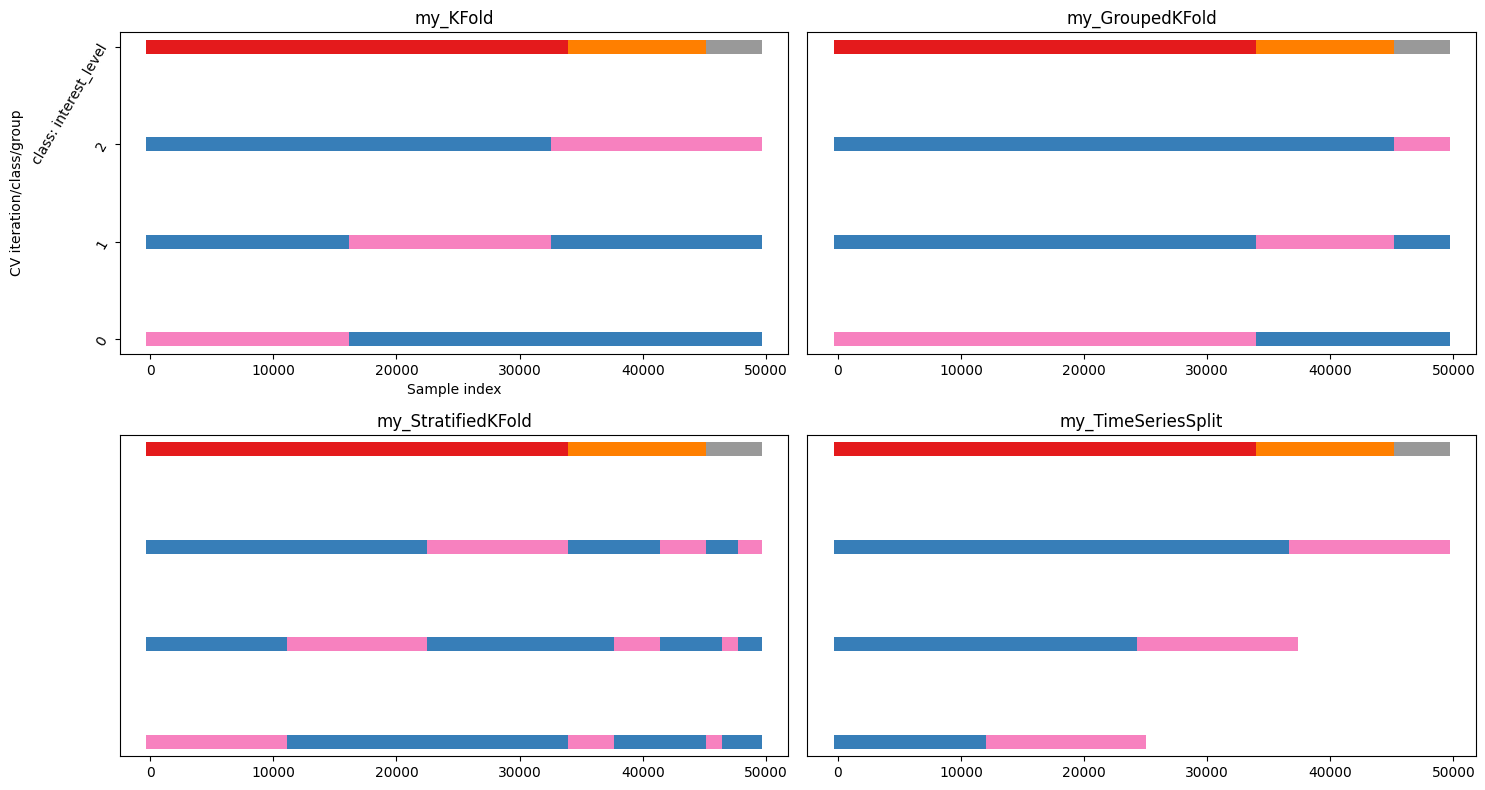

In [18]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))
k=3
for ax, cv in zip(
    (ax1, ax2, ax3, ax4),
    (my_KFold(X_s, y_s, k=k),
     my_GroupedKFold(X_s, y_s, k=k, group_field='interest_level'),
     my_StratifiedKFold(X_s, y_s, k=k, stratify_field='interest_level'),
    my_TimeSeriesSplit(X_s, y_s, k=k+1, by_date_field=False)
    )
):
    for ii, (tr, tt) in enumerate(cv):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=10,
            vmin=-0.2,
            vmax=1.2,
            cmap='Set1'
        )
    ax.scatter(range(len(X)), [ii + 1.5] * len(X), c=X['interest_level'].sort_values(), marker="_", lw=10, cmap='Set1')
    ax.set(yticks=[])
yticklabels = list(range(k)) + ["class: interest_level"]
ax1.set(
    yticks=np.arange(k + 1) + 0.5,
    yticklabels=yticklabels,
    xlabel="Sample index",
    ylabel="CV iteration/class/group",
    title='my_KFold',
);
ax1.tick_params(axis='y', rotation=60)
ax2.set(
    title='my_GroupedKFold'
);
ax3.set(
    title='my_StratifiedKFold'
);
ax4.set(
    title='my_TimeSeriesSplit'
);
fig.tight_layout()

In [19]:
my_StratifiedKFold(X, y, k=k, stratify_field='interest_level')

array([(array([16337, 16338, 16339, ..., 49349, 49350, 49351], shape=(32901,)), array([    1,     4,     5, ..., 16332, 16359, 16377], shape=(16451,))),
       (array([    0,     1,     2, ..., 49349, 49350, 49351], shape=(32901,)), array([16337, 16338, 16339, ..., 32871, 32872, 32887], shape=(16451,))),
       (array([    0,     1,     2, ..., 33068, 33070, 33073], shape=(32902,)), array([32837, 32838, 32839, ..., 49312, 49341, 49351], shape=(16450,)))],
      dtype=object)

- `StratifiedKFold` preserves share of each class both between folds and between train/test

In [20]:
for i, (train, test) in enumerate(my_StratifiedKFold(X, y, k=k, stratify_field='interest_level')):
    print(f"---FOLD {i}---")
    print("TRAIN")
    print(X.iloc[train]['interest_level'].value_counts() / len(train))
    print("TEST")
    print(X.iloc[test]['interest_level'].value_counts() / len(test))

---FOLD 0---
TRAIN
interest_level
0    0.694690
1    0.227531
2    0.077779
Name: count, dtype: float64
TEST
interest_level
0    0.694669
1    0.227524
2    0.077807
Name: count, dtype: float64
---FOLD 1---
TRAIN
interest_level
0    0.694690
1    0.227531
2    0.077779
Name: count, dtype: float64
TEST
interest_level
0    0.694669
1    0.227524
2    0.077807
Name: count, dtype: float64
---FOLD 2---
TRAIN
interest_level
0    0.694669
1    0.227524
2    0.077807
Name: count, dtype: float64
TEST
interest_level
0    0.694711
1    0.227538
2    0.077751
Name: count, dtype: float64


# 5. cross-validation comparison

- bin continuous `price` for stratification by target 

In [21]:
edges = [0, 10e2, 20e2, 30e2, 50e2, 10e3, 50e3, np.inf]
labels=['0-1k', '1k-2k', '2k-3k', '3k-5k', '5k-10k', '10k-50k', '50k+']
y_binned = pd.cut(y, bins=edges, labels=labels)

In [22]:
y_binned

4         2k-3k
6         3k-5k
9         3k-5k
10        2k-3k
15        2k-3k
          ...  
124000    2k-3k
124002    2k-3k
124004    1k-2k
124008    3k-5k
124009    3k-5k
Name: price, Length: 49352, dtype: category
Categories (7, object): ['0-1k' < '1k-2k' < '2k-3k' < '3k-5k' < '5k-10k' < '10k-50k' < '50k+']

### 1) sklearn.model_selection.StratifiedKFold vs. my_StratifiedKFold

In [23]:
my_stratified_kfold_ratios = pd.DataFrame({
    'category': labels
})

sklearn_stratified_kfold_ratios = pd.DataFrame({
    'category': labels
})

for i, (train, test) in enumerate(my_StratifiedKFold(X, y_binned, k=3, stratify_field='price')):
    train_shares = y_binned.iloc[train].value_counts() / len(train)
    my_stratified_kfold_ratios[f'my_train_fold_{i}'] = train_shares.values
    test_shares = y_binned.iloc[test].value_counts() / len(test)
    my_stratified_kfold_ratios[f'my_test_fold_{i}'] = test_shares.values

for i, (train, test) in enumerate(sklearn.model_selection.StratifiedKFold(n_splits=3).split(X, y_binned)):
    train_shares = y_binned.iloc[train].value_counts() / len(train)
    sklearn_stratified_kfold_ratios[f'sklearn_train_fold_{i}'] = train_shares.values
    test_shares = y_binned.iloc[test].value_counts() / len(test)
    sklearn_stratified_kfold_ratios[f'sklearn_test_fold_{i}'] = test_shares.values

- target classes ratios are the same for my_StratifiedKFold and sklearn.model_selection.StratifiedKFold:

In [24]:
my_stratified_kfold_ratios

,category,my_train_fold_0,my_test_fold_0,my_train_fold_1,my_test_fold_1,my_train_fold_2,my_test_fold_2
0,0-1k,0.390632,0.390543,0.390584,0.390638,0.390591,0.390625
1,1k-2k,0.361603,0.361553,0.361589,0.361581,0.361567,0.361625
2,2k-3k,0.122439,0.122463,0.122455,0.122432,0.122447,0.122446
3,3k-5k,0.107149,0.107147,0.107136,0.107173,0.107160,0.107125
4,5k-10k,0.017448,0.017503,0.017476,0.017447,0.017475,0.017449
5,10k-50k,0.000426,0.000425,0.000426,0.000426,0.000425,0.000426
6,50k+,0.000304,0.000365,0.000334,0.000304,0.000334,0.000304


In [25]:
sklearn_stratified_kfold_ratios

,category,sklearn_train_fold_0,sklearn_test_fold_0,sklearn_train_fold_1,sklearn_test_fold_1,sklearn_train_fold_2,sklearn_test_fold_2
0,0-1k,0.390626,0.390554,0.390596,0.390615,0.390584,0.390638
1,1k-2k,0.361570,0.361619,0.361600,0.361559,0.361589,0.361581
2,2k-3k,0.122428,0.122485,0.122458,0.122424,0.122455,0.122432
3,3k-5k,0.107170,0.107106,0.107140,0.107167,0.107136,0.107173
4,5k-10k,0.017446,0.017507,0.017477,0.017446,0.017476,0.017447
5,10k-50k,0.000426,0.000426,0.000426,0.000426,0.000426,0.000426
6,50k+,0.000334,0.000304,0.000304,0.000365,0.000334,0.000304


### 2) sklearn.model_selection.KFold vs. my_KFold

In [26]:
lin_reg = sklearn.linear_model.LinearRegression()
sklearn.model_selection.cross_val_score(lin_reg, X, y, cv=sklearn.model_selection.KFold(), scoring='neg_mean_squared_error')

array([-1.36755385e+08, -2.04014581e+09, -2.33208489e+08, -4.02538573e+06,
       -5.21130954e+06])

In [27]:
sklearn.model_selection.cross_val_score(lin_reg, X, y, cv=my_KFold(X, y), scoring='neg_mean_squared_error')

array([-1.36755385e+08, -2.04014581e+09, -2.33208489e+08, -4.02538573e+06,
       -5.21130954e+06])

### 3) sklearn.model_selection.GroupKFold vs. my_GroupedKFold

In [28]:
sklearn.model_selection.cross_val_score(lin_reg, X, y, cv=sklearn.model_selection.GroupKFold(n_splits=3).split(X=X, y=y, groups=X['interest_level']), scoring='neg_mean_squared_error')

array([-6.97302654e+08, -1.32389096e+06, -4.52599766e+06])

In [29]:
sklearn.model_selection.cross_val_score(lin_reg, X, y, cv=my_GroupedKFold(X, y, group_field='interest_level', k=3), scoring='neg_mean_squared_error')

array([-6.97302654e+08, -1.32389096e+06, -4.52599766e+06])

### 4) sklearn.model_selection.TimeSeriesSplit vs. my_TimeSeriesSplit

In [30]:
sklearn.model_selection.cross_val_score(lin_reg, X, y, cv=sklearn.model_selection.TimeSeriesSplit(), scoring='neg_mean_squared_error')

array([-2.44743051e+09, -2.79862210e+08, -2.77447411e+06, -4.51632223e+06,
       -5.78545035e+06])

In [31]:
sklearn.model_selection.cross_val_score(lin_reg, X, y, cv=my_TimeSeriesSplit(X, y, k=6, by_date_field=False), scoring='neg_mean_squared_error')

array([-2.44713295e+09, -2.79862210e+08, -2.77447411e+06, -4.51632223e+06,
       -5.78545035e+06])

--------------------------------------------------------------------------------

- Stratified CV can be useful here to deal with price outliers
- Time Split is irrelevant since there is no time-relations in the data (at least it is not provided as such)
- Group CV is also irrelevant since every sample stands for a unique object, and there is no risk of data leak between train/validation sets or train/test sets 

# 6. feature selection

In [32]:
data = data[feature_list + ['price']]
X = data[feature_list]
y = data['price']

- remove outliers

In [33]:
mask = y.between(y.quantile(0.01), y.quantile(0.99))

In [34]:
X = X[mask]
y = y[mask]

- split data into train, valid, test

In [35]:
X_train, X_valid, X_test, y_train, y_valid, y_test = my_data_split(X, y, test_size=0.2, validation_size=0.2)

- pipeline with MinMaxScaler and Lasso Regression

In [36]:
pipe = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.MinMaxScaler()),
    ('lasso', sklearn.linear_model.Lasso(alpha=10))
])

In [37]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


### Lasso feature importance

In [38]:
names = pipe.named_steps['scaler'].feature_names_in_
weights = pipe.named_steps['lasso'].coef_
features_importance = pd.DataFrame({
    'Name': names,
    'Importance': np.abs(weights)
}).sort_values(by='Importance', ascending=False)
features_importance.iloc[:12]

,Name,Importance
0,bathrooms,9833.059476
1,bedrooms,4242.939153
2,interest_level,861.632499
7,Doorman,588.203625
13,LaundryinUnit,442.245416
3,Elevator,155.321548
11,FitnessCenter,143.145220
16,DiningRoom,125.928711
10,LaundryinBuilding,109.714525
17,HighSpeedInternet,97.405278


In [39]:
MAE_results = pd.DataFrame({
    'model': ['Lasso MinMaxScaler'],
    'train': [sklearn.metrics.mean_absolute_error(y_pred=pipe.predict(X_train), y_true=y_train)],
    'valid': [sklearn.metrics.mean_absolute_error(y_pred=pipe.predict(X_valid), y_true=y_valid)],
    'test': [sklearn.metrics.mean_absolute_error(y_pred=pipe.predict(X_test), y_true=y_test)]
})

RMSE_results = pd.DataFrame({
    'model': ['Lasso MinMaxScaler'],
    'train': [sklearn.metrics.root_mean_squared_error(y_pred=pipe.predict(X_train), y_true=y_train)],
    'valid': [sklearn.metrics.root_mean_squared_error(y_pred=pipe.predict(X_valid), y_true=y_valid)],
    'test': [sklearn.metrics.root_mean_squared_error(y_pred=pipe.predict(X_test), y_true=y_test)]
})

R2_results = pd.DataFrame({
    'model': ['Lasso MinMaxScaler'],
    'train': [sklearn.metrics.r2_score(y_pred=pipe.predict(X_train), y_true=y_train)],
    'valid': [sklearn.metrics.r2_score(y_pred=pipe.predict(X_valid), y_true=y_valid)],
    'test': [sklearn.metrics.r2_score(y_pred=pipe.predict(X_test), y_true=y_test)]
})

In [40]:
MAE_results

,model,train,valid,test
0,Lasso MinMaxScaler,705.338808,712.428446,698.771498


In [41]:
RMSE_results

,model,train,valid,test
0,Lasso MinMaxScaler,1036.673172,1039.655375,1014.070771


In [42]:
R2_results

,model,train,valid,test
0,Lasso MinMaxScaler,0.583655,0.581823,0.576929


- now take top-10 features and fit model on them only

In [43]:
pipe_2 = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.MinMaxScaler()),
    ('lasso', sklearn.linear_model.Lasso(alpha=10))
])

In [44]:
lasso_top10_features = features_importance['Name'][:10]

In [45]:
pipe_2.fit(X_train[lasso_top10_features], y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [46]:

mae_results_lasso10 = {
    'model': 'Lasso top10 MinMaxScaler',
    'train': [sklearn.metrics.mean_absolute_error(y_pred=pipe_2.predict(X_train[lasso_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.mean_absolute_error(y_pred=pipe_2.predict(X_valid[lasso_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.mean_absolute_error(y_pred=pipe_2.predict(X_test[lasso_top10_features]), y_true=y_test)]
}
rmse_results_lasso10 = {
    'model': 'Lasso top10 MinMaxScaler',
    'train': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_2.predict(X_train[lasso_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_2.predict(X_valid[lasso_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_2.predict(X_test[lasso_top10_features]), y_true=y_test)]
}
r2_results_lasso10 = {
    'model': 'Lasso top10 MinMaxScaler',
    'train': [sklearn.metrics.r2_score(y_pred=pipe_2.predict(X_train[lasso_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.r2_score(y_pred=pipe_2.predict(X_valid[lasso_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.r2_score(y_pred=pipe_2.predict(X_test[lasso_top10_features]), y_true=y_test)]
}

In [47]:
MAE_results = pd.concat([MAE_results, pd.DataFrame(mae_results_lasso10)], axis=0, ignore_index=True)
RMSE_results = pd.concat([RMSE_results, pd.DataFrame(rmse_results_lasso10)], axis=0, ignore_index=True)
R2_results = pd.concat([R2_results, pd.DataFrame(r2_results_lasso10)], axis=0, ignore_index=True)

- model's **metrics practically did not change** after fitting on most relevant features selected by Lasso

In [48]:
MAE_results

,model,train,valid,test
0,Lasso MinMaxScaler,705.338808,712.428446,698.771498
1,Lasso top10 MinMaxScaler,707.397582,714.357001,701.474412


In [49]:
RMSE_results

,model,train,valid,test
0,Lasso MinMaxScaler,1036.673172,1039.655375,1014.070771
1,Lasso top10 MinMaxScaler,1038.737071,1041.571816,1017.004236


In [50]:
R2_results

,model,train,valid,test
0,Lasso MinMaxScaler,0.583655,0.581823,0.576929
1,Lasso top10 MinMaxScaler,0.581995,0.580280,0.574477


### Permutation importance

In [51]:
from my_validation import my_permutation_importance_MAPE

In [52]:
sklearn_permutation_results = sklearn.inspection.permutation_importance(pipe, X_valid, y_valid, scoring='neg_mean_absolute_percentage_error')
sklearn_permutation_results_df = pd.DataFrame({
    'sklearn_feature': X_train.columns,
    'sklearn_importance_mean': sklearn_permutation_results.importances_mean,
    'sklearn_importance_std': sklearn_permutation_results.importances_std,
}).sort_values(by='sklearn_importance_mean', ascending=False)

In [53]:
my_permutation_results = my_permutation_importance_MAPE(pipe, X_train, y_train)
my_permutation_results_df = pd.DataFrame({
    'my_feature': my_permutation_results['feature'],
    'my_importance_mean': my_permutation_results['importance_mean'],
    'my_importance_std': my_permutation_results['importance_std'],
}).sort_values(by='my_importance_mean', ascending=False)

- permutation importance put forward almost the same features: bedrooms, bathrooms, Doorman, interest_level etc.

In [54]:
pd.concat([sklearn_permutation_results_df, my_permutation_results_df], axis=1).iloc[:10]

,sklearn_feature,sklearn_importance_mean,sklearn_importance_std,my_feature,my_importance_mean,my_importance_std
1,bedrooms,0.091242,0.001220,bedrooms,0.092007,0.000892
0,bathrooms,0.048414,0.000797,bathrooms,0.048518,0.000633
7,Doorman,0.026589,0.000840,Doorman,0.028091,0.000417
2,interest_level,0.022987,0.000551,interest_level,0.023918,0.000352
13,LaundryinUnit,0.008755,0.000412,LaundryinUnit,0.008787,0.000243
3,Elevator,0.002754,0.000233,Elevator,0.002776,0.000111
11,FitnessCenter,0.001479,0.000074,FitnessCenter,0.001650,0.000094
8,Dishwasher,0.001124,0.000066,Dishwasher,0.000957,0.000044
16,DiningRoom,0.000613,0.000111,DiningRoom,0.000449,0.000072
10,LaundryinBuilding,0.000605,0.000101,LaundryinBuilding,0.000819,0.000088


- now refit the model using only features selected by permutation importance

In [55]:
permutation_top10_features = my_permutation_results_df['my_feature'][:10]

In [56]:
pipe_3 = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.MinMaxScaler()),
    ('lasso', sklearn.linear_model.Lasso(alpha=10))
])

In [57]:
pipe_3.fit(X_train[permutation_top10_features], y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [58]:
mae_results_perm10 = {
    'model': 'Lasso permutation MinMaxScaler',
    'train': [sklearn.metrics.mean_absolute_error(y_pred=pipe_3.predict(X_train[permutation_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.mean_absolute_error(y_pred=pipe_3.predict(X_valid[permutation_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.mean_absolute_error(y_pred=pipe_3.predict(X_test[permutation_top10_features]), y_true=y_test)]
}
rmse_results_perm10 = {
    'model': 'Lasso permutation MinMaxScaler',
    'train': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_3.predict(X_train[permutation_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_3.predict(X_valid[permutation_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_3.predict(X_test[permutation_top10_features]), y_true=y_test)]
}
r2_results_perm10 = {
    'model': 'Lasso permutation MinMaxScaler',
    'train': [sklearn.metrics.r2_score(y_pred=pipe_3.predict(X_train[permutation_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.r2_score(y_pred=pipe_3.predict(X_valid[permutation_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.r2_score(y_pred=pipe_3.predict(X_test[permutation_top10_features]), y_true=y_test)]
}

In [59]:
MAE_results = pd.concat([MAE_results, pd.DataFrame(mae_results_perm10)], axis=0, ignore_index=True)
RMSE_results = pd.concat([RMSE_results, pd.DataFrame(rmse_results_perm10)], axis=0, ignore_index=True)
R2_results = pd.concat([R2_results, pd.DataFrame(r2_results_perm10)], axis=0, ignore_index=True)

- once again, model's **metrics practically did not change** after fitting on most relevant features now selected by permutation importance

In [60]:
MAE_results

,model,train,valid,test
0,Lasso MinMaxScaler,705.338808,712.428446,698.771498
1,Lasso top10 MinMaxScaler,707.397582,714.357001,701.474412
2,Lasso permutation MinMaxScaler,706.607060,713.761392,700.503740


In [61]:
RMSE_results

,model,train,valid,test
0,Lasso MinMaxScaler,1036.673172,1039.655375,1014.070771
1,Lasso top10 MinMaxScaler,1038.737071,1041.571816,1017.004236
2,Lasso permutation MinMaxScaler,1039.032219,1042.287524,1016.525079


In [62]:
R2_results

,model,train,valid,test
0,Lasso MinMaxScaler,0.583655,0.581823,0.576929
1,Lasso top10 MinMaxScaler,0.581995,0.580280,0.574477
2,Lasso permutation MinMaxScaler,0.581758,0.579702,0.574878


### SHAP values

In [63]:
model = sklearn.linear_model.Lasso(alpha=10).fit(X_train, y_train)

In [64]:
explainer = shap.Explainer(model, X_train)

- SHAP values put forward almost the same features: bathrooms, bedrooms, Doorman, interest_level etc.

In [65]:
shap_values_df = pd.DataFrame({
    'feature': X_train.columns,
    'shap_value': np.abs(explainer.shap_values(X_train)).mean(axis=0)
}).sort_values(by='shap_value', ascending=False)

shap_values_df[:10]

,feature,shap_value
0,bathrooms,499.759971
1,bedrooms,446.419437
7,Doorman,265.878489
2,interest_level,219.313174
13,LaundryinUnit,99.938336
3,Elevator,68.965006
10,LaundryinBuilding,43.903561
11,FitnessCenter,39.620496
8,Dishwasher,26.191401
9,NoFee,19.380733


- now refit the model using only features selected by SHAP values

In [66]:
pipe_4 = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.MinMaxScaler()),
    ('lasso', sklearn.linear_model.Lasso(alpha=10))
])

In [67]:
shap_top10_features = shap_values_df['feature'][:10]

In [68]:
pipe_4.fit(X_train[shap_top10_features], y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [69]:
mae_results_shap10 = {
    'model': 'Lasso shap MinMaxScaler',
    'train': [sklearn.metrics.mean_absolute_error(y_pred=pipe_4.predict(X_train[shap_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.mean_absolute_error(y_pred=pipe_4.predict(X_valid[shap_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.mean_absolute_error(y_pred=pipe_4.predict(X_test[shap_top10_features]), y_true=y_test)]
}
rmse_results_shap10 = {
    'model': 'Lasso shap MinMaxScaler',
    'train': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_4.predict(X_train[shap_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_4.predict(X_valid[shap_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.root_mean_squared_error(y_pred=pipe_4.predict(X_test[shap_top10_features]), y_true=y_test)]
}
r2_results_shap10 = {
    'model': 'Lasso shap MinMaxScaler',
    'train': [sklearn.metrics.r2_score(y_pred=pipe_4.predict(X_train[shap_top10_features]), y_true=y_train)],
    'valid': [sklearn.metrics.r2_score(y_pred=pipe_4.predict(X_valid[shap_top10_features]), y_true=y_valid)],
    'test': [sklearn.metrics.r2_score(y_pred=pipe_4.predict(X_test[shap_top10_features]), y_true=y_test)]
}

In [70]:
MAE_results = pd.concat([MAE_results, pd.DataFrame(mae_results_shap10)], axis=0, ignore_index=True)
RMSE_results = pd.concat([RMSE_results, pd.DataFrame(rmse_results_shap10)], axis=0, ignore_index=True)
R2_results = pd.concat([R2_results, pd.DataFrame(r2_results_shap10)], axis=0, ignore_index=True)

- once again, model's **metrics practically did not change** after fitting on most relevant features now selected by SHAP values

In [71]:
MAE_results

,model,train,valid,test
0,Lasso MinMaxScaler,705.338808,712.428446,698.771498
1,Lasso top10 MinMaxScaler,707.397582,714.357001,701.474412
2,Lasso permutation MinMaxScaler,706.607060,713.761392,700.503740
3,Lasso shap MinMaxScaler,707.929634,715.140284,701.663322


In [72]:
RMSE_results

,model,train,valid,test
0,Lasso MinMaxScaler,1036.673172,1039.655375,1014.070771
1,Lasso top10 MinMaxScaler,1038.737071,1041.571816,1017.004236
2,Lasso permutation MinMaxScaler,1039.032219,1042.287524,1016.525079
3,Lasso shap MinMaxScaler,1039.631385,1042.897173,1016.956664


In [73]:
R2_results

,model,train,valid,test
0,Lasso MinMaxScaler,0.583655,0.581823,0.576929
1,Lasso top10 MinMaxScaler,0.581995,0.580280,0.574477
2,Lasso permutation MinMaxScaler,0.581758,0.579702,0.574878
3,Lasso shap MinMaxScaler,0.581275,0.579211,0.574517


# 7. hyperparameters optimization

In [74]:
from my_validation import my_GridSearchCV, my_RandomGridSearchCV

In [75]:
elastic_net_param = {
    'alpha': np.logspace(-4, 4, num=9, base=10.0),
    'l1_ratio': np.arange(0.1, 1, 0.1)
}

### basic GridSearchCV

In [76]:
my_GridSearchCV_results = my_GridSearchCV(
    sklearn.linear_model.ElasticNet, 
    elastic_net_param, 
    X_train, 
    y_train, 
    scorer=sklearn.metrics.mean_absolute_error, 
    cv=my_KFold(X_train, y_train, k=5))

my_GridSearchCV_results_df = pd.DataFrame(my_GridSearchCV_results).sort_values(by='score_mean')

  0%|          | 0/81 [00:00<?, ?it/s]

- basic GridSearch performed **81 iteration** over the given parameters grid

In [77]:
best_alpha = my_GridSearchCV_results_df.head(1).alpha.values
best_l1_ratio = my_GridSearchCV_results_df.head(1).l1_ratio.values
best_score = my_GridSearchCV_results_df.head(1).score_mean.values
print(f"best alpha: {best_alpha}")
print(f"best l1_ratio: {best_l1_ratio}")
print(f"best score: {best_score}")

best alpha: [0.1]
best l1_ratio: [0.9]
best score: [689.71664616]


In [78]:
my_GridSearchCV_results_df.head(3)

,alpha,l1_ratio,score_mean,score_std
35,0.10,0.9,689.716646,7.013395
18,0.01,0.1,689.779278,7.068761
19,0.01,0.2,689.818384,7.107202


### RandomGridSearchCV

In [79]:
my_RandomGridSearchCV_results = my_RandomGridSearchCV(
    sklearn.linear_model.ElasticNet, 
    elastic_net_param, 
    X_train, 
    y_train, 
    scorer=sklearn.metrics.mean_absolute_error, 
    cv=my_KFold(X_train, y_train, k=5),
    n_iter=10)

my_RandomGridSearchCV_results_df = pd.DataFrame(my_RandomGridSearchCV_results).sort_values(by='score_mean')

  0%|          | 0/10 [00:00<?, ?it/s]

- we configured RandomGridSearch to perform only **10 iterations** over the given parameters grid
- still, RandomGridSearch managed to find a combination with score almost similar to the one of basic GridSearch:

In [80]:
rnd_best_alpha = my_RandomGridSearchCV_results_df.head(1).alpha.values
rnd_best_l1_ratio = my_RandomGridSearchCV_results_df.head(1).l1_ratio.values
rnd_best_score = my_RandomGridSearchCV_results_df.head(1).score_mean.values
print(f"best alpha: {rnd_best_alpha}")
print(f"best l1_ratio: {rnd_best_l1_ratio}")
print(f"best score: {rnd_best_score}")

best alpha: [0.1]
best l1_ratio: [0.8]
best score: [689.92348192]


In [81]:
my_RandomGridSearchCV_results_df.head(3)

,alpha,l1_ratio,score_mean,score_std
8,0.100,0.8,689.923482,6.784582
6,0.010,0.5,690.003527,7.232623
7,0.001,0.2,690.457700,7.430840


### Optuna

In [82]:
import optuna

In [83]:
def objective(trial):

    k = 5
    cv = my_KFold(X_train, y_train, k=k)
    scorer = sklearn.metrics.mean_absolute_error
    
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)      # define parameters search range for optuna
    l1_ratio = trial.suggest_float('l1_ratio', 0, 1)

    estimator = sklearn.linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

    score = np.ndarray(k, dtype=float)

    for i, (train, test) in enumerate(cv): 

        y_pred = estimator.fit(X_train.iloc[train], y_train.iloc[train]).predict(X_train.iloc[test])
        fold_score = scorer(y_pred=y_pred, y_true=y_train.iloc[test])

        score[i] = fold_score

    return np.mean(score)

In [84]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

study.best_params  

[I 2025-12-15 12:42:33,709] A new study created in memory with name: no-name-6cc7330c-0d98-450b-a701-7bdda2ba6497
[I 2025-12-15 12:42:33,774] Trial 0 finished with value: 1037.1946291333802 and parameters: {'alpha': 8.073020498442636, 'l1_ratio': 0.3524995819920349}. Best is trial 0 with value: 1037.1946291333802.
[I 2025-12-15 12:42:33,809] Trial 1 finished with value: 1053.5839392120492 and parameters: {'alpha': 58.12231455030868, 'l1_ratio': 0.9041678389134346}. Best is trial 0 with value: 1037.1946291333802.
[I 2025-12-15 12:42:33,846] Trial 2 finished with value: 1062.2565791310985 and parameters: {'alpha': 13.501443328645701, 'l1_ratio': 0.467280301468496}. Best is trial 0 with value: 1037.1946291333802.
[I 2025-12-15 12:42:33,984] Trial 3 finished with value: 690.1121551811887 and parameters: {'alpha': 0.007226185395455461, 'l1_ratio': 0.47991354175782686}. Best is trial 3 with value: 690.1121551811887.
[I 2025-12-15 12:42:34,018] Trial 4 finished with value: 985.7163248191242 a

{'alpha': 0.007226185395455461, 'l1_ratio': 0.47991354175782686}

- in our experiment, optuna finds an optimal combination over a **continuous range of parameters** in **10 iterations**
- the best_score is similar or even better than that of full GridSearchCV:

In [85]:
print(f"GridSearchCV best score: {best_score[0]:.2f}")
print(f"RandomGridSearchCV best score: {rnd_best_score[0]:.2f}")
print(f"Optuna best score: {study.best_value:.2f}")

GridSearchCV best score: 689.72
RandomGridSearchCV best score: 689.92
Optuna best score: 690.11
